In [1]:
%matplotlib inline
__import__("os").environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [2]:
import os
import copy
import time
import numbers
import warnings
import matplotlib.pyplot as plt

import torch
import random
import numpy as np

seed=0
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [3]:
import sys
sys.path.append('../../..')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11.modules.detector import DetectionModel
from computer_vision.yolov11.modules.validator import DetectionValidator
from computer_vision.yolov11.modules.trainer import DetectionTrainer
from computer_vision.yolov11.parameter_parser import parser
from computer_vision.yolov11.utils.check import check_imgsz
from computer_vision.yolov11.data.dataset import YOLODataset

In [4]:
def show_batch(batch, ncols=4, imgsz=640):
    """
    Args:
        batch (dict[str,Any]): Training batch containing
            - `batch_idx` (torch.Tensor): (N,) image index of each item in the batch
            - `bboxes` (torch.Tensor): (N,4) bounding boxes in the normalized xywh format
            - `cls` (torch.Tensor): (N, 1) object classes
            - `im_file` (tuple[str]): filename of images in this batch
            - `img` (torch.Tensor): BxCxHxW where C is the number of image channels
            - `ori_shape` (tuple[tuple[int,int]]): Tuple of tuples of original (height, width) of all images in this batch 
            - `resized_shape` (tuple[tuple[int,int]]): Tuple of tuples of (height, width) of all input images in this batch 
        imgsz (int): image training size 
        ncols (int): number of columns
    """
    from matplotlib import patches
    from computer_vision.yolov11.utils.ops import xywhn2xyxy
    
    cmap = plt.get_cmap('tab10', 10)
    plt.rcParams.update({'font.size'   : 12})

    nrows=int(np.ceil(len(batch['im_file'])/ncols))
    boxes=xywhn2xyxy(batch['bboxes'], w=imgsz, h=imgsz)
    
    _, ax=plt.subplots(nrows,ncols,figsize=(20,20))
    for i in range(nrows):
        for j in range(ncols):
            idx=i*ncols+j
            if idx>len(batch['im_file'])-1: break
            valid_mask=batch['batch_idx']==idx
            img=batch['img'][idx] # CxHxW
            height, width=img.shape[1:]
            bboxes=boxes[valid_mask].numpy()
            
            ax[i,j].imshow(img.permute(1,2,0).contiguous().numpy())
            for k, box in enumerate(bboxes):
                # Create a Rectangle patch
                rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(k), facecolor='none')
                # Add the patch to the Axes
                ax[i,j].add_patch(rect)
                ax[i,j].text(*box[:2], f'{k}', color=cmap(k), fontsize=12)
    
    plt.tight_layout(pad=0, w_pad=0, h_pad=0)


In [5]:
data_dirpath=r'D:/data/ultralytics/coco'
result_dirpath='D:/results/yolov11/training'

argument=f'''--root {data_dirpath} --train-image-dirname images/train2017 --train-label-dirname labels/train2017
--val-image-dirname images/val2017 --val-label-dirname labels/val2017
--data-cfg ../coco.yaml --hyperparam ../default.yaml --model-cfg ../yolo11.yaml 
--batch-size 16 --output-dirpath {result_dirpath} --checkpoint-dirpath {result_dirpath}/checkpoints 
--epochs 200 --time 6.5  --print-freq 100''' # we want to see if we disable mosaic, do images having the same size for stacking?
# close_mosaic is set to 10, so it should stop mosaic at epoch 3
args=parser.parse_args(argument.split())

if not os.path.isdir(args.checkpoint_dirpath): os.makedirs(args.checkpoint_dirpath)

In [6]:
trainer=DetectionTrainer(args, cfg=args.hyperparam, inch=3)

Resume training with checkpoint directory set to D:/results/yolov11/training/checkpoints
In modules.trainer.DetectionTrainer.__init__ self.args.worker 2
In modules.trainer.DetectionTrainer._init__ self.args.resume  True


In [7]:
trainer.device

device(type='cuda')

In [8]:
trainer._setup_train()

nb=len(trainer.train_loader) # number of batches
nw=max(round(nb*trainer.args.warmup_epochs), 100) if trainer.args.warmup_epochs>0 else -1 # warmup iterations
last_opt_step=-1 # schedule start position
trainer.epoch_time=None
trainer.epoch_time_start=time.time() # in seconds
trainer.train_time_start=time.time()
print(f'Image sizes {trainer.args.imgsz} train\n'
      f'Using {trainer.train_loader.num_workers * (trainer.world_size or 1)} dataloader workers\n'
      f'Logging results to {trainer.save_dir}\n'
      "Starting training for "+(f'{trainer.args.time} hours ...' if trainer.args.time else f'{trainer.epochs} epochs ...')
     )
if trainer.args.close_mosaic>0: # number of epochs before the end to turning off mosaic
    base_idx=(trainer.epochs-trainer.args.close_mosaic)*nb # number of batches trained with mosaic
    trainer.plot_idx.extend([base_idx, base_idx+1, base_idx+2])

In module.trainer.DetectionTrainer._setup_train: Freezing layer model.23.dfl.conv.weight
In data.dataset.YOLODataset.update_images_labels cache path D:\data\ultralytics\coco\labels\train2017.cache exist. Load it!!!
Scanning D:\data\ultralytics\coco\labels\train2017.cache ... 117266 images with 1021 missing and 0 empty files as well as 0 corrupt files
In data.dataset.YOLODataset.__init__ max_buffer_length  128  ni  118287
In data.dataset.YOLODataset.update_images_labels cache path D:\data\ultralytics\coco\labels\val2017.cache exist. Load it!!!
Scanning D:\data\ultralytics\coco\labels\val2017.cache ... 4952 images with 48 missing and 0 empty files as well as 0 corrupt files
In data.dataset.YOLODataset.__init__ max_buffer_length  0  ni  5000
optimizer: "optimizer=auto" found, ignoring "lr0=0.01" and "momentum=0.937" and determining best "optimizer", "lr0", and "momentum" automatrically....
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups: 81 weight(decy=0.), 88 weight(decay=0.0

In [9]:
epoch=trainer.start_epoch
trainer.optimizer.zero_grad() # zero any resumed gradients 

#while True:
trainer.epoch=epoch
with warnings.catch_warnings():
    # Suppress `Detected lr_scheduler.step() nefore optimizer.step()`
    warnings.simplefilter('ignore') 
    trainer.scheduler.step()

# Set to model to training mode
trainer._model_train() # set model to train mode

if epoch==(trainer.epochs-trainer.args.close_mosaic):
    trainer._close_dataloader_mosaic()
    # Do we need to call this to reset the data loader
    # self.train_loader.iterator = self.train_loader._get_iterator()
    
trainer.tloss=None
for i, batch in enumerate(trainer.train_loader):
    break

batch_idx torch.Size([145])
bboxes torch.Size([145, 4])
cls torch.Size([145, 1])
im_file 16
img torch.Size([16, 3, 640, 640])
ori_shape 16
resized_shape 16


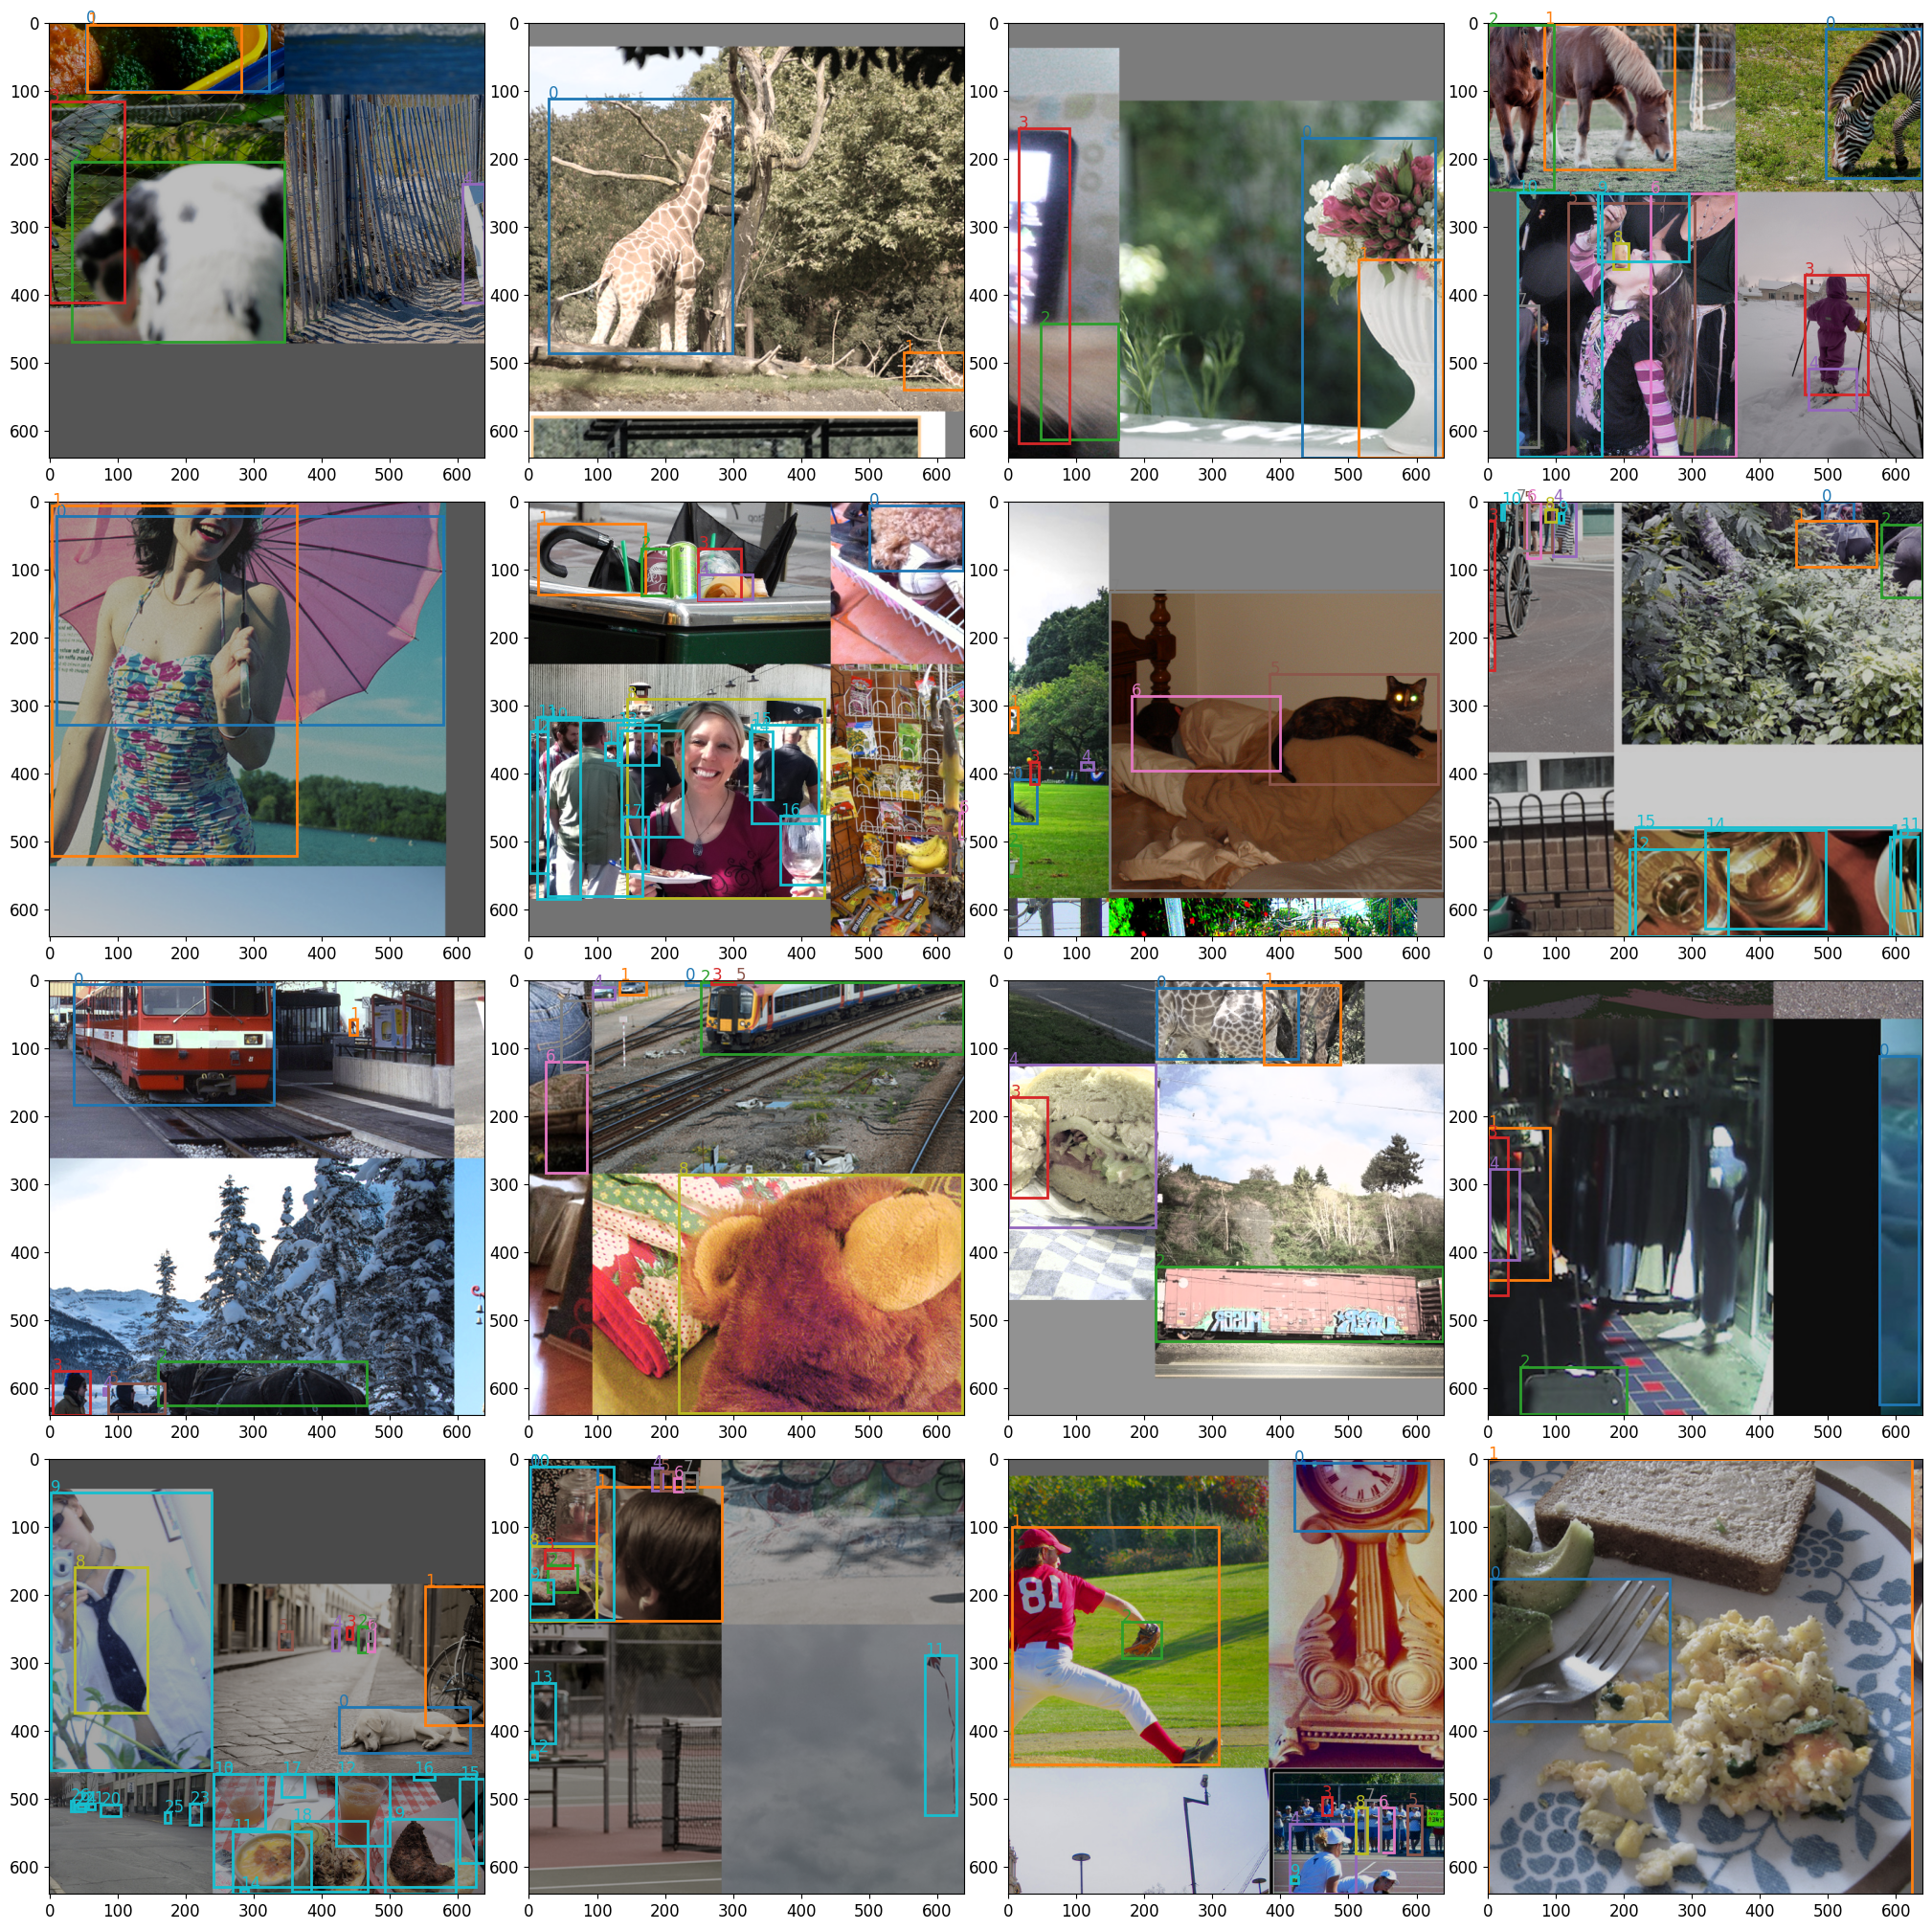

In [10]:
for name, item in batch.items():
    print(name, item.shape if isinstance(item, torch.Tensor) else len(item))
show_batch(batch, ncols=4, imgsz=640)

In [11]:
# Warmup
ni=i+nb*epoch
if ni<=nw:
    xi=[0,nw]
    trainer.accumulate=max(1, int(np.interp(ni, xi, [1, trainer.args.nbs/trainer.batch_size]).round()))
    print('trainer.accumulate ', trainer.accumulate)
    for j, x in enumerate(trainer.optimizer.param_groups):
        # if optimizer is not `auto`, bias lr falls from 0.1 to lr0 while all other lrs rise from 0. to lr0;
        # otherwise, all lrs rise from 0 to lr0
        x['lr']=np.interp(ni, xi, [trainer.args.warmup_bias_lr if j==0 else 0., x['initial_lr']*trainer.lf(epoch)])
        if 'momentum' in x: x['momentum']=np.interp(ni, xi, [trainer.args.warmup_momentum, trainer.args.momentum])
        print(f"j {j}, x['lr'] {x['lr']}, x['momentum'] {x['momentum']}")

trainer.accumulate  1
j 0, x['lr'] 0.0, x['momentum'] 0.8
j 1, x['lr'] 0.0, x['momentum'] 0.8
j 2, x['lr'] 0.0, x['momentum'] 0.8


In [12]:
# Forward: if amp scaling is use the whole forward section has to be under with autocast(trainer.amp)
batch=trainer.preprocess_batch(batch)

In [13]:
from computer_vision.yolov11.utils.loss import v8DetectionLoss

hyp=trainer.args
if getattr(trainer.model, 'criterion', None) is None: trainer.model.criterion=v8DetectionLoss(args=hyp, model=trainer.model)
preds=trainer.model.forward(batch['img'])

In [14]:
loss, trainer.loss_items=trainer.model.criterion(preds, batch) 
print('loss ', loss)
print('trainer.loss_items ', trainer.loss_items)
trainer.loss=loss.sum()
print('trainer.loss ', trainer.loss)
# compute moving average loss
trainer.tloss=trainer.loss_items if trainer.tloss is None else (trainer.tloss*i+trainer.loss_items)/(i+1)
print('trainer.tloss ', trainer.tloss)

loss  tensor([55.1149, 92.8351, 67.6341], device='cuda:0', grad_fn=<MulBackward0>)
trainer.loss_items  tensor([3.4447, 5.8022, 4.2271], device='cuda:0')
trainer.loss  tensor(215.5841, device='cuda:0', grad_fn=<SumBackward0>)
trainer.tloss  tensor([3.4447, 5.8022, 4.2271], device='cuda:0')


In [15]:
# Backward
# self.scaler.scale(self.loss).backward()
trainer.loss.backward()
if ni-last_opt_step >= trainer.accumulate:
    trainer.optimizer.step()
    last_opt_step=ni
    print('optimizer steps')
    
    # Timed stopping
    if trainer.args.time: # in hours
        trainer.stop=(time.time()-trainer.train_time_start)>(trainer.args.time*3600)
        # if trainer.stop: break # training time exceed we need to check this in the loop 

optimizer steps


In [16]:
# Log   
loss_length=trainer.tloss.shape[0] if len(trainer.tloss.shape) else 1
print('loss_length ', loss_length)
if isinstance(trainer.args.print_freq, numbers.Number) and (i+1)%trainer.args.print_freq==0:
    print('Epoch: {}, Iter: {}/{}({:.2f}%), Mem: {}GB, Box: {:.3f}, Cls: {:.3f}, DFL: {:.3f}, Time: {:.2f}s, N:{}, Img:{}'.format(epoch+1, i, nb,
                                  100*i/nb, trainer._get_memory(), trainer.tloss[0] if len(trainer.tloss)>0 else 0, 
                                  trainer.tloss[1] if len(trainer.tloss)>1 else 0,
                                  trainer.tloss[2] if len(trainer.tloss)>2 else 0, time.time()-start_it_time,
                                  batch['cls'].shape[0], batch['img'].shape[-1]))

loss_length  3


In [18]:
start_it_time=0
print('Epoch: {}, Iter: {}/{}({:.2f}%), Mem: {}GB, Box: {:.3f}, Cls: {:.3f}, DFL: {:.3f}, Time: {:.2f}s, N:{}, Img:{}'.format(epoch+1, i, nb,
                                  100*i/nb, trainer._get_memory(), trainer.tloss[0] if len(trainer.tloss)>0 else 0, 
                                  trainer.tloss[1] if len(trainer.tloss)>1 else 0,
                                  trainer.tloss[2] if len(trainer.tloss)>2 else 0, time.time()-start_it_time,
                                  batch['cls'].shape[0], batch['img'].shape[-1]))

Epoch: 1, Iter: 0/7392(0.00%), Mem: 4.75GB, Box: 3.445, Cls: 5.802, DFL: 4.227, Time: 1762244161.95s, N:145, Img:640
